# dem4cli v2 demo

## Description 

Updates compared to original version of Wim/Luke
- **life expectancy data** 
    - updated from UNWPP2019 to UNWPP2024
    - Input data: years left to live at age 5 (e(x) for x=5). As in original version, this is converted to life expectancy at birth, neglecting child mortality, and adding 6 extra years to life expectancy to go from cohort to period life expectancy. 
    - Previously was extrapolated for later birth years (from 2013 to 2020) by holding the life expectancy constant and was interpolated for exact years because data was provided at 5-year snapshots. Now does not need to be extrapolated for later birth years because this data is now available 1950-2023 (estimates) but also 2024-2100 (projections, medium variant), and does not need to be interpolated because provided for exact years. 
    - You can therefore have this data for all birth years 1945-2095. In the standard settings life expectancy is provided for birth years 1950-2025 
    - Previously only available starting from birth year 1960? Not sure why because original UNWPP2019 data also has data 1950-1955. 
- **cohort size data** 
    - Updated from WCDE v2 (SSPs of CMIP6) to 2 options: can now come from WCDE (SSP v3.2-beta, i.e. CMIP7 projections), as snapshots every 5 years for 5-year age groups, or from UNWPP2024, for exact years/ages. In both cases estimates and projections are both provided, for the period 1950-2100. 
    - WCDE data needs interpolation of ages/years, which I corrected to be mean-preserving. UNWPP2024 does not need interpolation. 
    - UNWPP2024 seems similar to WCDE v3.2 SSP2.  
    - *to test*: integrate in wrapper function, see how many countries now available
- **available countries**
    - 185 countries available instead of 177, based on data availability and WB region categorization, when using cohorts from SSP v3.2
    - *to check*: how many if cohorts from UNWPP? 
- **country masks**
    - added option to get it from fractional country masks ISIpedia, so you don't lose small countries and coastal population. 
    - *to do*: make it an option whether to choose shapefiles or fractional country masks, for having also sub-national analysis
- **spatial resolution**
    - available now at 0.5 and 0.1 degrees (depends on population data and gridded / fractional country masks, if using )
- **gridded population data**
    - updated from ISIMIP2 data to COMPASS data (gridded and harmonized at national level with SSPs v3.2-beta), from Dominik
    - available at 0.5 and 0.1 resolution as count of number of people
    - *note*: in dem4cli v1 there is option to use ISIMIP3 population data 


## Functions

**Part 1. Demographics preprocesing**

- **load_cohort_sizes()** loads cohort sizes reconstructions and projections
    - v2 option 1: WCDE v3.2-beta (flags['cohort_sizes_source'] ='WCDE') from SSPs, estimates until 2025, projections thereafter, for 5-year snapshots and 5-year age groups (no uncertainties, can pick SSP). 
    - v2 option 2: UNWPP2024 (flags['cohort_sizes_source'] = 'UNWPP2024'), estimates until 2023, projections thereafter (with uncertainties), for exact ages/years >*finish testing*
- **interpolate_cohortsize_countries()** interpolates from 5-year age brackets to exact ages, only necessary for WCDE
- **load_population()** loads gridded pop data
    - dem4cli v2: from COMPASS (pre-CMIP7 version, harmonized with SSP v3.2-beta at national level)
- **load_unwpp_lifeexpectancy()** loads and cleans life expectancy data e(x) at age 5 from UNWPP2024
    - UNWPP2024 provides estimates 1950-2023 and projections 2024-2100, for exact ages/years
- **get_life_expectancies()** goes from raw e(x) data period -> cohort life expectancy at age 0 neglecting child mortality
- **load_countrymasks_fillcoasts()** loads fractional countrymasks, with options for filling coastal pixels to sum to 1 
    - TODO: see whether to do this or stick to shapefiles
- wrapper function that runs everything: **preprocess_all_country_data()**
    - option to give a bounding box 

## To do:
- wrapper function option to cut years in other data not just pop data??? 
- test wrapper fxn with cohorts from UNWPP2024, see how many countries are kept, include it here in the demo!
- make country mask shapefile/gridded an option and if gridded integrate in Lexp functions


**Part 2. Lifetime exposure**
- GMT mapping 
- lifetime exposure functions








In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
#import regionmask
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
%matplotlib inline 

sys.path.append('..')
from population_demographics_v2 import * 

In [2]:
flags

# TODO: maake init function where

{'version': 2,
 'pop_resolution': 0.5,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024'}

In [3]:
bbox_europe = [ 31.99,  71.09, -14.96,  34.94]

## Part 1. Demographics preprocessing

### a) individual functions

In [4]:
df_metadata = load_country_metadata(
    filepath_isimip_countries = os.path.join(script_dir, 'data/country-masks/isipedia-countries/countryData.json'),
    filepath_world_bank = os.path.join(script_dir, 'data/income-groups/world_bank/CLASS.xlsx'), # what year is this from? 
    keep_names='isimip',
    keep_stats=False,
)

In [9]:
df_unwpp = load_unwpp_lifeexpectancy(filepath_lifeexpectancy = filepath_lifeexpectancy) # load life expectancy data and clean 
df_life_expectancy_5 = get_life_expectancies(df_unwpp,
                                            start_birthyear=1950,
                                            end_birthyear=2025) # go from 'period' to 'cohort' life expectancy

# NOTE: names here are 'UNWPP names' in metadata table

In [8]:
df_cohort_sizes_wcde, ages, years = load_cohort_sizes(dir_cohortsizes =  os.path.join(data_dir, 'cohort-sizes/WCDE_v3.2.beta'), 
                                                    ssp=2, 
                                                    data_source = 'WCDE',
                                                    by_sex=False)

# loads raw cohort size data from historical + ssp and cleans to keep only relevant information

# TODO: note that could get this from UNWPP2024! 

loading cohort sizes from WCDE


In [17]:
from math import ceil 

endyear = ceil(max(df_life_expectancy_5.values.flatten()) + 2025)
endyear

2119

In [ ]:
da_cohort_size_wcde = interpolate_cohortsize_countries(
                        df_cohort_sizes_wcde,
                        ages,
                        years,
                        data_source = 'WCDE',
                        startyear= 1950,
                        endyear = endyear, # have to still implement for UNWPP ! 
                    )

# interpolates cohort sizes from 5 year to single year and corrects to preserve mean
# SSP names 

# TODO: with this new data the neg numbers happens more, check if this is big or small issue

interpolating cohort sizes per country
after interpolation and mean-preserving correction there are some neg numbers in 6, Anguilla, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 44, Comoros, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 74, Gabon, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 127, Mali, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 128, Malta, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 173, Rwanda, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 183, San Marino, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 198, South Sudan, setting them to zero
after interpolation and mean-preservi

### testing

In [26]:
da_cohort_size_wcde

<xarray.DataArray 'cohort_size' (country: 236, time: 170, ages: 105)>
array([[[ 2.73567360e+02,  2.61743480e+02,  2.49919600e+02, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 2.73309184e+02,  2.62139952e+02,  2.50970720e+02, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 2.73051008e+02,  2.62536424e+02,  2.52021840e+02, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 1.03772627e+03,  1.05063030e+03,  1.06353432e+03, ...,
          5.86251401e-01,  0.00000000e+00,  0.00000000e+00],
        [ 1.02940217e+03,  1.04259342e+03,  1.05578468e+03, ...,
          6.04562957e-01,  0.00000000e+00,  0.00000000e+00],
        [ 1.02107806e+03,  1.03455655e+03,  1.04803504e+03, ...,
          6.22874514e-01,  0.00000000e+00,  0.00000000e+00]],

       [[ 3.90316400e+01,  3.79113200e+01,  3.67910000e+01, ...,
          1.99376947e-03,  0.00000000e+00,  0.00000000e+00],
        [ 4.13674160e+01,  4.00184880e+01,  3.86695600e+01, ...,
          2.18182113e-03,  0.00000000e+00,  0.00000000e+00],
        [ 4.37031920e+01,  4.21256560e+01,  4.05481200e+01, ...,
          2.36987279e-03,  0.00000000e+00,  0.00000000e+00],
...
        [ 4.52143800e+02,  4.55289760e+02,  4.58435720e+02, ...,
          4.59118518e-01,  0.00000000e+00,  0.00000000e+00],
        [ 4.48682600e+02,  4.51836240e+02,  4.54989880e+02, ...,
          4.71474424e-01,  0.00000000e+00,  0.00000000e+00],
        [ 4.45221400e+02,  4.48382720e+02,  4.51544040e+02, ...,
          4.83830330e-01,  0.00000000e+00,  0.00000000e+00]],

       [[ 1.02697080e+02,  9.89636400e+01,  9.52302000e+01, ...,
          3.92156863e-04,  0.00000000e+00,  0.00000000e+00],
        [ 1.10939600e+02,  1.06367600e+02,  1.01795600e+02, ...,
          3.55979011e-04,  0.00000000e+00,  0.00000000e+00],
        [ 1.19182120e+02,  1.13771560e+02,  1.08361000e+02, ...,
          3.19801160e-04,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 2.10384824e+02,  2.12831432e+02,  2.15278040e+02, ...,
          1.12851590e+00,  0.00000000e+00,  0.00000000e+00],
        [ 2.08054536e+02,  2.10519248e+02,  2.12983960e+02, ...,
          1.16285643e+00,  0.00000000e+00,  0.00000000e+00],
        [ 2.05724248e+02,  2.08207064e+02,  2.10689880e+02, ...,
          1.19719695e+00,  0.00000000e+00,  0.00000000e+00]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 ... 96 97 98 99 100 101 102 103 104

<Axes: xlabel='time'>

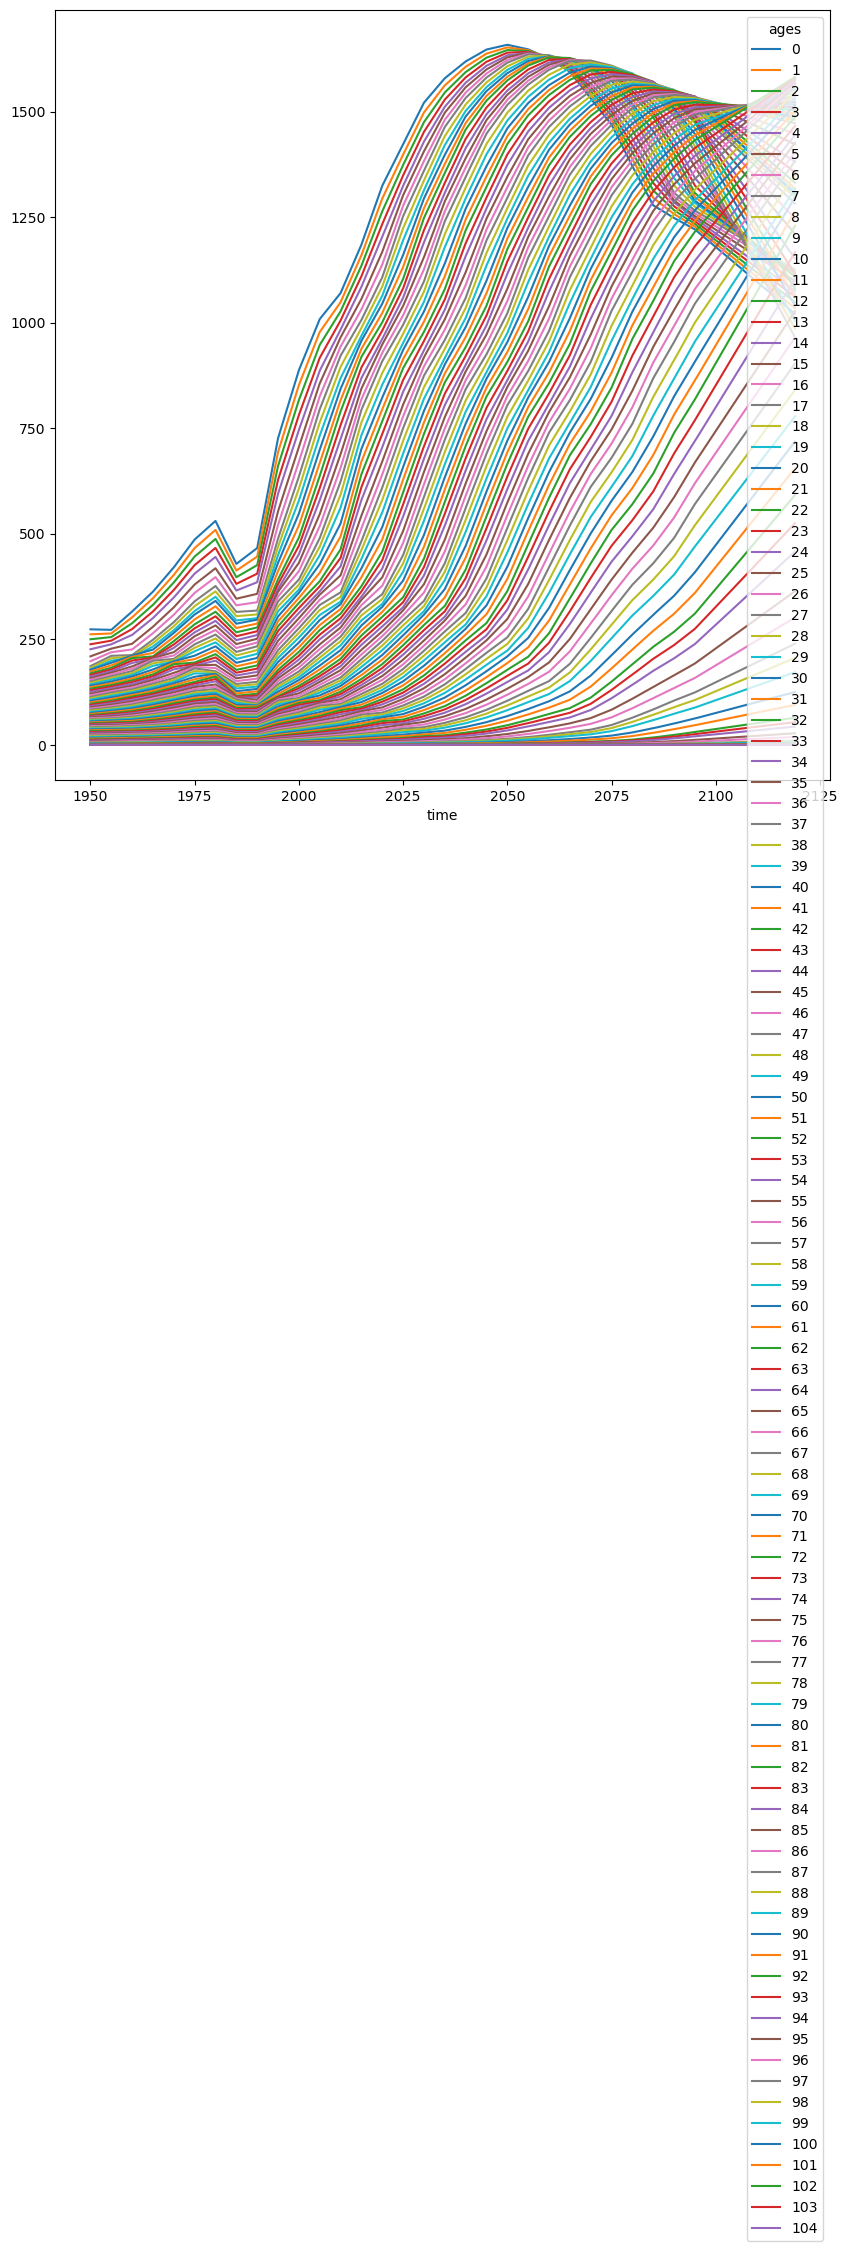

In [25]:
da_cohort_size_wcde.sel(country='Afghanistan').to_pandas().plot(figsize=(10,10))

In [27]:
df_cohort_sizes_unwpp, ages, years = load_cohort_sizes(dir_cohortsizes =  dir_cohortsizes, 
                                                    ssp=None, 
                                                    data_source = 'UNWPP2024',
                                                    by_sex=False)

loading cohort sizes from UNWPP2024


In [28]:
df_cohort_sizes_unwpp

<xarray.DataArray (ages: 100, country: 237, time: 151)>
array([[[3.1581850e+02, 3.1596150e+02, 3.2254100e+02, ...,
         1.8121300e+03, 1.8078235e+03, 1.8011550e+03],
        [4.4996000e+01, 4.7037000e+01, 4.9370500e+01, ...,
         7.3635000e+00, 7.2780000e+00, 7.1850000e+00],
        [3.7315250e+02, 4.0705050e+02, 4.1599500e+02, ...,
         6.0000900e+02, 5.9824750e+02, 5.9676000e+02],
        ...,
        [1.9274850e+02, 1.9069000e+02, 1.9590250e+02, ...,
         1.3801885e+03, 1.3714585e+03, 1.3632210e+03],
        [1.0203000e+02, 1.0746950e+02, 1.1039450e+02, ...,
         9.2323600e+02, 9.2014900e+02, 9.1798000e+02],
        [1.2761300e+02, 1.3197050e+02, 1.3534650e+02, ...,
         5.0170500e+02, 4.9895500e+02, 4.9595450e+02]],

       [[2.6917450e+02, 2.6723850e+02, 2.6814350e+02, ...,
         1.8131700e+03, 1.8097570e+03, 1.8048325e+03],
        [3.9432000e+01, 4.0547500e+01, 4.2429500e+01, ...,
         7.4565000e+00, 7.3585000e+00, 7.2730000e+00],
        [3.0553350e+02, 3.4287700e+02, 3.7440050e+02, ...,
         6.0132050e+02, 5.9920000e+02, 5.9751500e+02],
...
        [1.5500000e-02, 1.2500000e-02, 1.0000000e-02, ...,
         7.5390000e+00, 7.9440000e+00, 8.3665000e+00],
        [4.0000000e-03, 4.5000000e-03, 4.0000000e-03, ...,
         4.6720000e+00, 4.9775000e+00, 5.3015000e+00],
        [7.5000000e-03, 7.5000000e-03, 5.5000000e-03, ...,
         4.3135000e+00, 4.6890000e+00, 5.0470000e+00]],

       [[5.0000000e-04, 5.0000000e-04, 0.0000000e+00, ...,
         3.9200000e+00, 4.1835000e+00, 4.4495000e+00],
        [1.0500000e-02, 9.0000000e-03, 8.0000000e-03, ...,
         4.1160000e+00, 4.0945000e+00, 3.9620000e+00],
        [1.5300000e-01, 1.4550000e-01, 1.2700000e-01, ...,
         4.4002000e+01, 4.5875500e+01, 4.7732500e+01],
        ...,
        [9.5000000e-03, 9.0000000e-03, 7.5000000e-03, ...,
         4.6705000e+00, 4.9535000e+00, 5.2310000e+00],
        [2.5000000e-03, 3.0000000e-03, 3.5000000e-03, ...,
         3.0565000e+00, 3.2730000e+00, 3.4925000e+00],
        [4.5000000e-03, 5.0000000e-03, 5.5000000e-03, ...,
         2.8000000e+00, 3.1050000e+00, 3.3800000e+00]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 9 ... 90 91 92 93 94 95 96 97 98 99

In [37]:
from scipy.interpolate import interp1d

def extend_da_slinear(da, endyear):
    """
    Extend DataArray along 'time' using linear extrapolation.
    Fully vectorized, works for any extra dims.
    """
    # numeric years
    if np.issubdtype(da.time.dtype, np.datetime64):
        years = da['time.year'].values
    else:
        years = da['time'].values
    
    # new full range
    new_years = np.arange(years[0], endyear + 1)
    
    # reshape for interpolation: (time, N) where N = product of all non-time dims
    orig_shape = da.shape
    n_time = orig_shape[0]
    other_dims_shape = orig_shape[1:]
    da_flat = da.values.reshape(n_time, -1)  # shape = (time, N)
    
    # interpolate along axis=0 (time)
    f = interp1d(years, da_flat, kind='linear', axis=0, fill_value='extrapolate', bounds_error=False)
    extended_flat = f(new_years)  # shape = (new_time, N)
    
    # reshape back to (new_time, ...) 
    extended_vals = extended_flat.reshape((len(new_years),) + other_dims_shape)
    
    # assign new DataArray
    extended_da = xr.DataArray(
        extended_vals,
        coords={**{dim: da.coords[dim] for dim in da.dims if dim != 'time'}, 'time': new_years},
        dims=da.dims
    )
    
    return extended_da



In [38]:
extended_da = extend_da_slinear(df_cohort_sizes_unwpp, endyear)

ValueError: x and y arrays must be equal in length along interpolation axis.

### continue

In [36]:
df_cohort_sizes_unwpp.shape

(100, 237, 151)

In [33]:
years

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026,
       2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037,
       2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048,
       2049, 2050, 2051, 2052, 2053, 2054, 2055, 2056, 2057, 2058, 2059,
       2060, 2061, 2062, 2063, 2064, 2065, 2066, 2067, 2068, 2069, 2070,
       2071, 2072, 2073, 2074, 2075, 2076, 2077, 2078, 2079, 2080, 2081,
       2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089, 2090, 2091, 2092,
       2093, 2094, 2095, 2096, 2097, 2098, 2099, 21

In [32]:
da_population = load_population(
    dir_population= dir_population, 
    startyear=1950,
    endyear=2100,
    ssp=2,
    urbanrural=False,
    bbox = bbox_europe # optional : latmin, latmax, lonmin, lonmax

)

# load gridded population data, crop over Europe (optional cropping)


opening compass - historical
opening compass - ssp2


In [33]:
# open country masks

da_countrymasks = load_countrymasks_fillcoasts(
                            filepath_countrymask,
                            preprocess=False, # True if you want to preprocess
                            fillcoast=False, # fill coastal pixels to not lose coastal pops (done in preprocessed files)
                            fix_smallislands=False, # done in preprocessed input files for 0.5, not for 0.1 - TODO: check if necessary at 0.1 or not ! 
                            bbox=bbox_europe,
                            )

# these are already preprocessed (cleaned country names and coastal pixels are filled to sum to 1 to not lose population)
# abbrevs



In [34]:
# lookup table

df_lookuptable = pd.read_csv(filepath_lookuptable) # new - matches all sources




### b) wrapper function (Global)

In [35]:
# wrapper function that runs everything for S2S / lifetime exposure calcs

d_countries = preprocess_all_country_data(

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    ssp=2, 
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025, 

    dir_population= dir_population,     # gridded pop data 
    startyear=1950,
    endyear=2100,
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    bbox = None,

    filepath_countrymask = filepath_countrymask,    # country masks 
    preprocess=False,                               # NOTE preprocessing is already done in standard input files 
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_lookuptable = filepath_lookuptable,    # country filtering
    filter_countries=True,
    worldbank_filter=True, 

    )

# TODO: see if Amaury needs other objects I didn't include in d_countries 
# 'birth_years' and 'mask' I am not sure... 



interpolating cohort sizes per country
after interpolation and mean-preserving correction there are some neg numbers in 6, Anguilla, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 15, Bahrain, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 29, British Virgin Islands, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 32, Burkina Faso, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 39, Central African Republic, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 61, El Salvador, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 65, Eswatini, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 68, Faroe Islands, setting them t

### Check data

#### a) from raw functions

In [36]:
df_metadata # = intersection of ISIMIP mask and World Bank official country list

,country,abbreviation,country_code,region,incomegroup
0,Afghanistan,AFG,3,South Asia,Low income
1,Albania,ALB,103,Europe & Central Asia,Upper middle income
2,Algeria,DZA,203,Middle East & North Africa,Upper middle income
3,Andorra,AND,403,Europe & Central Asia,High income
4,Angola,AGO,503,Sub-Saharan Africa,Lower middle income
...,...,...,...,...,...
190,Venezuela (Bolivarian Republic of),VEN,22503,Latin America & Caribbean,NaN
191,Viet Nam,VNM,22603,East Asia & Pacific,Lower middle income
192,Yemen,YEM,23003,Middle East & North Africa,Low income
193,Zambia,ZMB,23103,Sub-Saharan Africa,Lower middle income


In [37]:
da_cohort_size # from ssps 

# NOTE! overlap between mask, UNWPP and SSP projections is 218 countries 

# NOTE! of these only 198 countries have full cohort size projections into future!

# TODO could check if with UNWPP cohort size projections this is better / more country coverage

<xarray.DataArray 'cohort_size' (country: 236, time: 151, ages: 105)>
array([[[2.73567360e-01, 2.61743480e-01, 2.49919600e-01, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.73309184e-01, 2.62139952e-01, 2.50970720e-01, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.73051008e-01, 2.62536424e-01, 2.52021840e-01, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [1.19588425e+00, 1.20333086e+00, 1.21077748e+00, ...,
         2.38331824e-04, 0.00000000e+00, 0.00000000e+00],
        [1.18756014e+00, 1.19529399e+00, 1.20302784e+00, ...,
         2.56643380e-04, 0.00000000e+00, 0.00000000e+00],
        [1.17923604e+00, 1.18725712e+00, 1.19527820e+00, ...,
         2.74954937e-04, 0.00000000e+00, 0.00000000e+00]],

       [[3.90316400e-02, 3.79113200e-02, 3.67910000e-02, ...,
         1.99376947e-06, 0.00000000e+00, 0.00000000e+00],
        [4.13674160e-02, 4.00184880e-02, 3.86695600e-02, ...,
         2.18182113e-06, 0.00000000e+00, 0.00000000e+00],
        [4.37031920e-02, 4.21256560e-02, 4.05481200e-02, ...,
         2.36987279e-06, 0.00000000e+00, 0.00000000e+00],
...
        [5.17906600e-01, 5.20906640e-01, 5.23906680e-01, ...,
         2.24356300e-04, 0.00000000e+00, 0.00000000e+00],
        [5.14445400e-01, 5.17453120e-01, 5.20460840e-01, ...,
         2.36712206e-04, 0.00000000e+00, 0.00000000e+00],
        [5.10984200e-01, 5.13999600e-01, 5.17015000e-01, ...,
         2.49068113e-04, 0.00000000e+00, 0.00000000e+00]],

       [[1.02697080e-01, 9.89636400e-02, 9.52302000e-02, ...,
         3.92156863e-07, 0.00000000e+00, 0.00000000e+00],
        [1.10939600e-01, 1.06367600e-01, 1.01795600e-01, ...,
         3.55979011e-07, 0.00000000e+00, 0.00000000e+00],
        [1.19182120e-01, 1.13771560e-01, 1.08361000e-01, ...,
         3.19801160e-07, 0.00000000e+00, 0.00000000e+00],
        ...,
        [2.54660296e-01, 2.56762928e-01, 2.58865560e-01, ...,
         4.76045919e-04, 0.00000000e+00, 0.00000000e+00],
        [2.52330008e-01, 2.54450744e-01, 2.56571480e-01, ...,
         5.10386444e-04, 0.00000000e+00, 0.00000000e+00],
        [2.49999720e-01, 2.52138560e-01, 2.54277400e-01, ...,
         5.44726970e-04, 0.00000000e+00, 0.00000000e+00]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 ... 96 97 98 99 100 101 102 103 104

In [38]:
da_population

<xarray.DataArray 'total-population' (time: 151, lat: 78, lon: 100)>
dask.array<concatenate, shape=(151, 78, 100), dtype=float32, chunksize=(1, 78, 100), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
  * lon      (lon) float64 -14.75 -14.25 -13.75 -13.25 ... 33.75 34.25 34.75
  * lat      (lat) float64 70.75 70.25 69.75 69.25 ... 33.75 33.25 32.75 32.25
Attributes:
    long_name:  Population_count
    units:      1

In [ ]:
df_life_expectancy_5

# life expectancy at age 5 (corrected to be at birth and period) for each country/birth year - last estimate data is for 2018 birth year, thereafter they are projections - all available from UNWPP2024



Country,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antigua and Barbuda,Argentina,Armenia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela (Bolivarian Republic of),Viet Nam,Wallis and Futuna Islands,Western Sahara,Yemen,Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
1950,54.7051,72.2933,60.0833,73.0935,78.4736,60.3326,71.0196,72.9259,73.9860,73.5868,...,76.9994,71.5994,62.5983,68.7405,68.7827,60.0066,58.8167,63.0338,68.3711,67.5054
1951,54.9914,73.1170,59.9968,73.3142,78.7848,60.4601,71.3453,73.1271,74.8442,73.7835,...,77.1543,71.7428,63.0074,69.2576,69.2194,60.2678,59.0545,63.2106,68.5591,67.7423
1952,55.3287,74.0791,59.8907,73.5873,79.0685,60.5222,71.6498,73.3441,74.3825,73.9763,...,77.3030,71.8910,63.3789,69.7610,69.5801,60.5338,59.2911,63.3482,68.7140,67.9825
1953,55.6465,75.0774,59.7686,74.0095,79.4490,60.5925,71.9511,73.5912,75.4063,74.1662,...,77.4524,72.0515,63.7587,70.2772,69.9530,60.8083,59.5263,63.5801,68.9539,68.2102
1954,55.9651,75.9208,59.6571,74.5568,79.7661,60.6646,72.3025,73.8626,75.2090,74.3545,...,77.5948,72.2161,64.1316,70.8107,70.2969,61.0874,59.7591,63.7344,69.1736,68.4717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,75.9220,86.3595,83.9010,79.6241,90.5553,75.0080,85.7620,84.3227,84.1949,82.4296,...,84.6663,79.3779,78.7511,79.8957,82.1112,85.6520,79.4421,78.1426,75.9474,71.7437
2022,75.9220,86.3595,83.9010,79.6241,90.5553,75.0080,85.7620,84.3227,84.1949,82.4296,...,84.6663,79.3779,78.7511,79.8957,82.1112,85.6520,79.4421,78.1426,75.9474,71.7437
2023,75.9220,86.3595,83.9010,79.6241,90.5553,75.0080,85.7620,84.3227,84.1949,82.4296,...,84.6663,79.3779,78.7511,79.8957,82.1112,85.6520,79.4421,78.1426,75.9474,71.7437


In [40]:
da_countrymasks

<xarray.DataArray (lat: 78, lon: 100, country: 50)>
dask.array<getitem, shape=(78, 100, 50), dtype=float32, chunksize=(78, 100, 44), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -14.75 -14.25 -13.75 -13.25 ... 33.75 34.25 34.75
  * lat      (lat) float64 70.75 70.25 69.75 69.25 ... 33.75 33.25 32.75 32.25
  * country  (country) object 'ALB' 'AND' 'AUT' 'BEL' ... 'TUN' 'TUR' 'UKR'

#### b) from wrapper function (filtered country list)

Wrapper function runs all functions and then filters object based on data available in all datasets, and optionally in World Bank regions / income level categorization, so that all the objects are coherent

Global, matching on data availability = 198 countries

Global, matching based on data availability and world bank inclusion = 185 countries


In [ ]:
df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] # NOTE: not a gdf anymore! its now da_countrymasks
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
#df_birthyears = d_countries['birth_years'] # NA
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
#countries_regions, countries_mask = d_countries['mask'] # NA 

In [42]:
df_countries

,country,region,incomegroup,country_code,SSP name,WPP name
abbreviation,,,,,,
AFG,Afghanistan,South Asia,Low income,3,Afghanistan,Afghanistan
ALB,Albania,Europe & Central Asia,Upper middle income,103,Albania,Albania
DZA,Algeria,Middle East & North Africa,Upper middle income,203,Algeria,Algeria
AGO,Angola,Sub-Saharan Africa,Lower middle income,503,Angola,Angola
ATG,Antigua and Barbuda,Latin America & Caribbean,High income,703,Antigua and Barbuda,Antigua and Barbuda
...,...,...,...,...,...,...
VEN,Venezuela (Bolivarian Republic of),Latin America & Caribbean,NaN,22503,Venezuela,Venezuela (Bolivarian Republic of)
VNM,Viet Nam,East Asia & Pacific,Lower middle income,22603,Viet Nam,Viet Nam
YEM,Yemen,Middle East & North Africa,Low income,23003,Yemen,Yemen


In [43]:
gdf_country_borders

<xarray.DataArray (lat: 360, lon: 720, country: 185)>
dask.array<getitem, shape=(360, 720, 185), dtype=float32, chunksize=(299, 604, 151), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * country  (country) object 'AFG' 'AGO' 'ALB' 'ARE' ... 'ZAF' 'ZMB' 'ZWE'

In [44]:
da_regions

array(['South Asia', 'Europe & Central Asia',
       'Middle East & North Africa', 'Sub-Saharan Africa',
       'Latin America & Caribbean', 'East Asia & Pacific',
       'North America'], dtype=object)

In [45]:
da_population

<xarray.DataArray 'total-population' (time: 151, lat: 360, lon: 720)>
dask.array<concatenate, shape=(151, 360, 720), dtype=float32, chunksize=(1, 360, 720), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
Attributes:
    long_name:  Population_count
    units:      1

In [46]:
df_life_expectancy_5

Country,Afghanistan,Albania,Algeria,Angola,Antigua and Barbuda,Argentina,Armenia,Australia,Austria,Azerbaijan,...,United Kingdom,United States of America,Uruguay,Uzbekistan,Vanuatu,Venezuela (Bolivarian Republic of),Viet Nam,Yemen,Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
1950,54.7051,72.2933,60.0833,60.3326,72.9259,73.9860,73.5868,78.1507,77.3280,66.0148,...,78.2731,77.8523,76.9994,71.5994,62.5983,68.7405,68.7827,63.0338,68.3711,67.5054
1951,54.9914,73.1170,59.9968,60.4601,73.1271,74.8442,73.7835,77.9627,77.2763,66.2382,...,78.4502,77.9013,77.1543,71.7428,63.0074,69.2576,69.2194,63.2106,68.5591,67.7423
1952,55.3287,74.0791,59.8907,60.5222,73.3441,74.3825,73.9763,78.2529,77.0455,66.4249,...,78.5535,77.6759,77.3030,71.8910,63.3789,69.7610,69.5801,63.3482,68.7140,67.9825
1953,55.6465,75.0774,59.7686,60.5925,73.5912,75.4063,74.1662,78.6761,77.7793,66.6800,...,78.6526,77.9369,77.4524,72.0515,63.7587,70.2772,69.9530,63.5801,68.9539,68.2102
1954,55.9651,75.9208,59.6571,60.6646,73.8626,75.2090,74.3545,78.3229,77.7012,67.0317,...,78.7528,78.1150,77.5948,72.2161,64.1316,70.8107,70.2969,63.7344,69.1736,68.4717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,75.9220,86.3595,83.9010,75.0080,84.3227,84.1949,82.4296,90.2420,88.2412,81.7448,...,87.6458,85.7930,84.6663,79.3779,78.7511,79.8957,82.1112,78.1426,75.9474,71.7437
2022,75.9220,86.3595,83.9010,75.0080,84.3227,84.1949,82.4296,90.2420,88.2412,81.7448,...,87.6458,85.7930,84.6663,79.3779,78.7511,79.8957,82.1112,78.1426,75.9474,71.7437
2023,75.9220,86.3595,83.9010,75.0080,84.3227,84.1949,82.4296,90.2420,88.2412,81.7448,...,87.6458,85.7930,84.6663,79.3779,78.7511,79.8957,82.1112,78.1426,75.9474,71.7437


In [47]:
da_cohort_size

<xarray.DataArray 'cohort_size' (country: 185, time: 151, ages: 105)>
array([[[2.73567360e-01, 2.61743480e-01, 2.49919600e-01, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.73309184e-01, 2.62139952e-01, 2.50970720e-01, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.73051008e-01, 2.62536424e-01, 2.52021840e-01, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [1.19588425e+00, 1.20333086e+00, 1.21077748e+00, ...,
         2.38331824e-04, 0.00000000e+00, 0.00000000e+00],
        [1.18756014e+00, 1.19529399e+00, 1.20302784e+00, ...,
         2.56643380e-04, 0.00000000e+00, 0.00000000e+00],
        [1.17923604e+00, 1.18725712e+00, 1.19527820e+00, ...,
         2.74954937e-04, 0.00000000e+00, 0.00000000e+00]],

       [[3.90316400e-02, 3.79113200e-02, 3.67910000e-02, ...,
         1.99376947e-06, 0.00000000e+00, 0.00000000e+00],
        [4.13674160e-02, 4.00184880e-02, 3.86695600e-02, ...,
         2.18182113e-06, 0.00000000e+00, 0.00000000e+00],
        [4.37031920e-02, 4.21256560e-02, 4.05481200e-02, ...,
         2.36987279e-06, 0.00000000e+00, 0.00000000e+00],
...
        [5.17906600e-01, 5.20906640e-01, 5.23906680e-01, ...,
         2.24356300e-04, 0.00000000e+00, 0.00000000e+00],
        [5.14445400e-01, 5.17453120e-01, 5.20460840e-01, ...,
         2.36712206e-04, 0.00000000e+00, 0.00000000e+00],
        [5.10984200e-01, 5.13999600e-01, 5.17015000e-01, ...,
         2.49068113e-04, 0.00000000e+00, 0.00000000e+00]],

       [[1.02697080e-01, 9.89636400e-02, 9.52302000e-02, ...,
         3.92156863e-07, 0.00000000e+00, 0.00000000e+00],
        [1.10939600e-01, 1.06367600e-01, 1.01795600e-01, ...,
         3.55979011e-07, 0.00000000e+00, 0.00000000e+00],
        [1.19182120e-01, 1.13771560e-01, 1.08361000e-01, ...,
         3.19801160e-07, 0.00000000e+00, 0.00000000e+00],
        ...,
        [2.54660296e-01, 2.56762928e-01, 2.58865560e-01, ...,
         4.76045919e-04, 0.00000000e+00, 0.00000000e+00],
        [2.52330008e-01, 2.54450744e-01, 2.56571480e-01, ...,
         5.10386444e-04, 0.00000000e+00, 0.00000000e+00],
        [2.49999720e-01, 2.52138560e-01, 2.54277400e-01, ...,
         5.44726970e-04, 0.00000000e+00, 0.00000000e+00]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 ... 96 97 98 99 100 101 102 103 104

### c) Testing wrapper function with a bounding box (Europe)

In [48]:
d_countries = preprocess_all_country_data(

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    ssp=2, 
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025, 

    dir_population= dir_population,     # gridded pop data 
    startyear=1950,
    endyear=2100,
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    bbox = bbox_europe,

    filepath_countrymask = filepath_countrymask,    # country masks 
    preprocess=False,                               # NOTE preprocessing is already done in standard input files 
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_lookuptable = filepath_lookuptable,    # country filtering - TODO: could make this more flexible
    filter_countries=True,
    worldbank_filter=True, 

    )

interpolating cohort sizes per country
after interpolation and mean-preserving correction there are some neg numbers in 6, Anguilla, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 15, Bahrain, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 29, British Virgin Islands, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 32, Burkina Faso, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 39, Central African Republic, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 61, El Salvador, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 65, Eswatini, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 68, Faroe Islands, setting them t

In [49]:
df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] # NOTE: not a gdf anymore! (da_countrymasks)
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
#df_birthyears = d_countries['birth_years']
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
#countries_regions, countries_mask = d_countries['mask']

In [50]:
gdf_country_borders

<xarray.DataArray (lat: 78, lon: 100, country: 47)>
dask.array<getitem, shape=(78, 100, 47), dtype=float32, chunksize=(78, 100, 41), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -14.75 -14.25 -13.75 -13.25 ... 33.75 34.25 34.75
  * lat      (lat) float64 70.75 70.25 69.75 69.25 ... 33.75 33.25 32.75 32.25
  * country  (country) object 'ALB' 'AUT' 'BEL' 'BGR' ... 'TUN' 'TUR' 'UKR'

In [51]:
df_life_expectancy_5

Country,Albania,Algeria,Austria,Belarus,Belgium,Bosnia and Herzegovina,Bulgaria,Croatia,Cyprus,Czechia,...,Serbia,Slovakia,Slovenia,Spain,Sweden,Switzerland,Tunisia,Türkiye,Ukraine,United Kingdom
Year,,,,,,,,,,,,,,,,,,,,,
1950,72.2933,60.0833,77.3280,75.3355,77.8648,70.1355,78.4307,76.3165,72.2451,77.3027,...,74.7094,77.6059,76.3769,77.7527,80.1749,78.3759,62.9397,74.2150,76.4168,78.2731
1951,73.1170,59.9968,77.2763,75.7719,78.0135,70.4649,77.6914,76.5287,72.5645,77.5200,...,75.0297,77.7876,76.4921,77.2738,80.2190,78.4089,63.4908,74.3061,76.7791,78.4502
1952,74.0791,59.8907,77.0455,76.1716,78.1412,71.1500,78.6301,76.8597,72.8389,77.1233,...,75.8287,77.2865,76.5532,77.2174,80.0601,78.6051,64.2125,73.4723,77.1535,78.5535
1953,75.0774,59.7686,77.7793,76.8768,78.4919,71.7558,79.5434,77.0930,73.1858,77.9136,...,76.5709,78.4581,76.8142,78.9503,80.5827,79.2188,64.7408,72.9428,77.3328,78.6526
1954,75.9208,59.6571,77.7012,77.8036,78.8723,72.8119,77.5044,77.2357,73.5729,77.6762,...,77.1057,77.8273,77.0635,78.8173,80.8428,79.4077,65.2574,73.5414,77.8302,78.7528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,86.3595,83.9010,88.2412,80.6127,88.4329,84.3144,82.0629,84.8911,87.9378,86.0489,...,83.1490,84.7730,87.7839,89.9109,89.4571,90.2568,83.3301,84.1688,79.9343,87.6458
2022,86.3595,83.9010,88.2412,80.6127,88.4329,84.3144,82.0629,84.8911,87.9378,86.0489,...,83.1490,84.7730,87.7839,89.9109,89.4571,90.2568,83.3301,84.1688,79.9343,87.6458
2023,86.3595,83.9010,88.2412,80.6127,88.4329,84.3144,82.0629,84.8911,87.9378,86.0489,...,83.1490,84.7730,87.7839,89.9109,89.4571,90.2568,83.3301,84.1688,79.9343,87.6458


In [52]:
da_cohort_size

<xarray.DataArray 'cohort_size' (country: 47, time: 151, ages: 105)>
array([[[3.90316400e-02, 3.79113200e-02, 3.67910000e-02, ...,
         1.99376947e-06, 0.00000000e+00, 0.00000000e+00],
        [4.13674160e-02, 4.00184880e-02, 3.86695600e-02, ...,
         2.18182113e-06, 0.00000000e+00, 0.00000000e+00],
        [4.37031920e-02, 4.21256560e-02, 4.05481200e-02, ...,
         2.36987279e-06, 0.00000000e+00, 0.00000000e+00],
        ...,
        [9.83215200e-03, 9.92873600e-03, 1.00253200e-02, ...,
         3.95880000e-03, 2.88510400e-03, 1.81140800e-03],
        [9.76001600e-03, 9.85228800e-03, 9.94456000e-03, ...,
         4.00560000e-03, 2.96615200e-03, 1.92670400e-03],
        [9.68788000e-03, 9.77584000e-03, 9.86380000e-03, ...,
         4.05240000e-03, 3.04720000e-03, 2.04200000e-03]],

       [[3.06626880e-01, 2.95139040e-01, 2.83651200e-01, ...,
         4.12400098e-05, 0.00000000e+00, 0.00000000e+00],
        [3.32316352e-01, 3.18029536e-01, 3.03742720e-01, ...,
         3.73115044e-05, 2.58489555e-07, 0.00000000e+00],
        [3.58005824e-01, 3.40920032e-01, 3.23834240e-01, ...,
         3.33829989e-05, 5.16979111e-07, 0.00000000e+00],
...
        [2.21298320e-01, 2.23299400e-01, 2.25300480e-01, ...,
         2.67173600e-02, 1.65655520e-02, 6.41374400e-03],
        [2.19785720e-01, 2.21675680e-01, 2.23565640e-01, ...,
         2.64344800e-02, 1.61270160e-02, 5.81955200e-03],
        [2.18273120e-01, 2.20051960e-01, 2.21830800e-01, ...,
         2.61516000e-02, 1.56884800e-02, 5.22536000e-03]],

       [[9.25836000e-01, 8.94793600e-01, 8.63751200e-01, ...,
         2.39706671e-05, 0.00000000e+00, 0.00000000e+00],
        [8.89918456e-01, 8.68049048e-01, 8.46179640e-01, ...,
         2.73262880e-05, 0.00000000e+00, 0.00000000e+00],
        [8.54000912e-01, 8.41304496e-01, 8.28608080e-01, ...,
         3.06819089e-05, 0.00000000e+00, 0.00000000e+00],
        ...,
        [6.98868872e-01, 7.01145656e-01, 7.03422440e-01, ...,
         1.64096960e-01, 1.13136200e-01, 6.21754400e-02],
        [6.97559776e-01, 6.99508648e-01, 7.01457520e-01, ...,
         1.68692480e-01, 1.17723040e-01, 6.67536000e-02],
        [6.96250680e-01, 6.97871640e-01, 6.99492600e-01, ...,
         1.73288000e-01, 1.22309880e-01, 7.13317600e-02]]])
Coordinates:
  * country  (country) object 'Albania' 'Algeria' ... 'Ukraine' 'United Kingdom'
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 ... 96 97 98 99 100 101 102 103 104

In [54]:
da_regions

array(['Europe & Central Asia', 'Middle East & North Africa'],
      dtype=object)

In [55]:
da_population

<xarray.DataArray 'total-population' (time: 151, lat: 78, lon: 100)>
dask.array<concatenate, shape=(151, 78, 100), dtype=float32, chunksize=(1, 78, 100), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
  * lon      (lon) float64 -14.75 -14.25 -13.75 -13.25 ... 33.75 34.25 34.75
  * lat      (lat) float64 70.75 70.25 69.75 69.25 ... 33.75 33.25 32.75 32.25
Attributes:
    long_name:  Population_count
    units:      1

## Part 2. Lifetime exposure

In [53]:
# GMT-mapping + lifetime exposure functions

# TODO 


